# Getting Started with scikit-learn (Linnerud Regression)

scikit-learn (or sklearn) is a popular Python library that provides simple and efficient tools for data mining and machine learning. It offers easy-to-use implementations of many supervised and unsupervised algorithms, plus utilities for data preprocessing, model evaluation, and pipeline building.

## What is Regression?
Regression is a type of supervised machine learning used to predict continuous numerical values. Unlike classification (which predicts categories), regression is useful when the target variable is a number—such as house prices, temperature, or weight.

## Models We Will Use
- **Linear Regression**: Fits a straight line to the data using ordinary least squares.
- **Decision Tree Regressor**: Non-linear model that splits data into regions based on feature thresholds.
- **Random Forest Regressor**: Ensemble of decision trees that averages predictions to reduce overfitting.

## Prerequisites

Install the required libraries if you haven't already:

```bash
pip install scikit-learn numpy pandas matplotlib
```

We'll use:
- **scikit-learn**: ML models, data loading, evaluation
- **numpy**: Numerical operations
- **pandas**: Data exploration
- **matplotlib**: Visualization

## Step 1: Import Required Libraries

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# scikit-learn tools
from sklearn.datasets import load_linnerud  # Load dataset
from sklearn.model_selection import train_test_split  # Split data
from sklearn.linear_model import LinearRegression  # Linear regression
from sklearn.tree import DecisionTreeRegressor  # Decision tree
from sklearn.ensemble import RandomForestRegressor  # Random forest
from sklearn.metrics import mean_squared_error, r2_score  # Evaluation metrics

## Step 2: Load and Explore the Linnerud Dataset

The `load_linnerud()` dataset contains physiological measurements and exercise data from 20 middle-aged men in a fitness club.

**Features (3 exercise variables):**
- `Chins`: Number of chin-ups performed
- `Situps`: Number of sit-ups performed
- `Jumps`: Number of jumping jacks performed

**Targets (3 physiological variables):**
- `Weight`: Body weight (lbs)
- `Waist`: Waist measurement (inches)
- `Pulse`: Pulse rate (beats/min)

In [2]:
# Load the dataset
linnerud = load_linnerud()

# Print dataset description
print(linnerud.DESCR)

print("\nFeature Names:", linnerud.feature_names)
print("Target Names:", linnerud.target_names)
print("\nData Shape:", linnerud.data.shape)
print("Target Shape:", linnerud.target.shape)

.. _linnerrud_dataset:

Linnerrud dataset
-----------------

**Data Set Characteristics:**

:Number of Instances: 20
:Number of Attributes: 3
:Missing Attribute Values: None

The Linnerud dataset is a multi-output regression dataset. It consists of three
exercise (data) and three physiological (target) variables collected from
twenty middle-aged men in a fitness club:

- *physiological* - CSV containing 20 observations on 3 physiological variables:
   Weight, Waist and Pulse.
- *exercise* - CSV containing 20 observations on 3 exercise variables:
   Chins, Situps and Jumps.

.. dropdown:: References

   * Tenenhaus, M. (1998). La regression PLS: theorie et pratique. Paris:
     Editions Technic.


Feature Names: ['Chins', 'Situps', 'Jumps']
Target Names: ['Weight', 'Waist', 'Pulse']

Data Shape: (20, 3)
Target Shape: (20, 3)


In [3]:
# Create DataFrame for features
df = pd.DataFrame(linnerud.data, columns=linnerud.feature_names)
# Add target columns
for i, name in enumerate(linnerud.target_names):
    df[name] = linnerud.target[:, i]

print("First 5 Rows of the Dataset:")
print(df.head())

print("\nDataset Statistics:")
print(df.describe())

First 5 Rows of the Dataset:
   Chins  Situps  Jumps  Weight  Waist  Pulse
0    5.0   162.0   60.0   191.0   36.0   50.0
1    2.0   110.0   60.0   189.0   37.0   52.0
2   12.0   101.0  101.0   193.0   38.0   58.0
3   12.0   105.0   37.0   162.0   35.0   62.0
4   13.0   155.0   58.0   189.0   35.0   46.0

Dataset Statistics:
           Chins      Situps      Jumps      Weight      Waist      Pulse
count  20.000000   20.000000   20.00000   20.000000  20.000000  20.000000
mean    9.450000  145.550000   70.30000  178.600000  35.400000  56.100000
std     5.286278   62.566575   51.27747   24.690505   3.201973   7.210373
min     1.000000   50.000000   25.00000  138.000000  31.000000  46.000000
25%     4.750000  101.000000   39.50000  160.750000  33.000000  51.500000
50%    11.500000  122.500000   54.00000  176.000000  35.000000  55.000000
75%    13.250000  210.000000   85.25000  191.500000  37.000000  60.500000
max    17.000000  251.000000  250.00000  247.000000  46.000000  74.000000


## Step 3: Visualize the Data

Let's explore the relationship between exercises and physiological measurements.

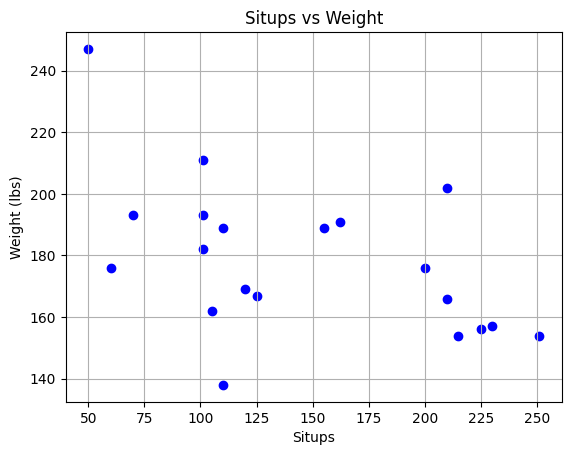

In [4]:
# Scatter plot: Situps vs Weight
plt.scatter(linnerud.data[:, 1], linnerud.target[:, 0], color='blue')
plt.title('Situps vs Weight')
plt.xlabel('Situps')
plt.ylabel('Weight (lbs)')
plt.grid(True)
plt.show()

## Step 4: Prepare Data for Modeling

We'll predict **Weight** using all 3 exercise features. Then compare multiple regression models.

In [5]:
# X = all features (Chins, Situps, Jumps)
X = linnerud.data
# y = target: Weight (first column)
y = linnerud.target[:, 0]

# Split data: 70% train, 30% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

Training samples: 14
Test samples: 6


## Step 5: Train Multiple Regression Models

We'll train three different regression models and compare their performance.

In [6]:
# Dictionary to store models and their names
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42)
}

# Train each model and store predictions
predictions = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions[name] = y_pred
    print(f"{name} trained.")

Linear Regression trained.
Decision Tree trained.
Random Forest trained.


### Linear Regression - Coefficients (Feature Importance)

In [ ]:
# Print Linear Regression coefficients
lr = models['Linear Regression']
print("Linear Regression Coefficients:")
for feature, coef in zip(linnerud.feature_names, lr.coef_):
    print(f"  {feature}: {coef:.2f}")
print(f"Intercept: {lr.intercept_:.2f}")
print(f"\nEquation: Weight = {lr.intercept_:.2f} + {lr.coef_[0]:.2f}*Chins + {lr.coef_[1]:.2f}*Situps + {lr.coef_[2]:.2f}*Jumps")

## Step 6: Make Predictions

Let's see how each model predicts on the test set.

In [7]:
# Compare first 5 actual vs predicted values for each model
comparison = pd.DataFrame({'Actual': y_test[:5]})
for name, y_pred in predictions.items():
    comparison[name] = y_pred[:5]

print("First 5 Actual vs Predicted Weight (lbs):")
print(comparison)

First 5 Actual vs Predicted Weight (lbs):
   Actual  Linear Regression  Decision Tree  Random Forest
0   191.0         163.355913          189.0         170.39
1   157.0         142.574714          156.0         161.37
2   202.0         156.899373          166.0         164.27
3   189.0         182.186848          138.0         161.03
4   176.0         148.744762          167.0         165.66


## Step 7: Evaluate Model Performance

We use two standard regression metrics:
- **Mean Squared Error (MSE)**: Lower = better
- **R² Score**: 0–1 (higher = better; 1 = perfect prediction)

In [9]:
results = []
for name, y_pred in predictions.items():
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results.append({'Model': name, 'MSE': round(mse, 2), 'R² Score': round(r2, 4)})
    print(f"{name}:")
    print(f"  MSE: {mse:.2f}")
    print(f"  R² Score: {r2:.4f}\n")

results_df = pd.DataFrame(results)
print("\nModel Comparison Summary:")
print(results_df)

Linear Regression:
  MSE: 632.89
  R² Score: -2.1996

Decision Tree:
  MSE: 804.00
  R² Score: -3.0646

Random Forest:
  MSE: 473.28
  R² Score: -1.3926


Model Comparison Summary:
               Model     MSE  R² Score
0  Linear Regression  632.89   -2.1996
1      Decision Tree  804.00   -3.0646
2      Random Forest  473.28   -1.3926


## Step 8: Visualize Predictions vs Actual

Plot predictions from each model against the actual values. The red dashed line represents perfect predictions.

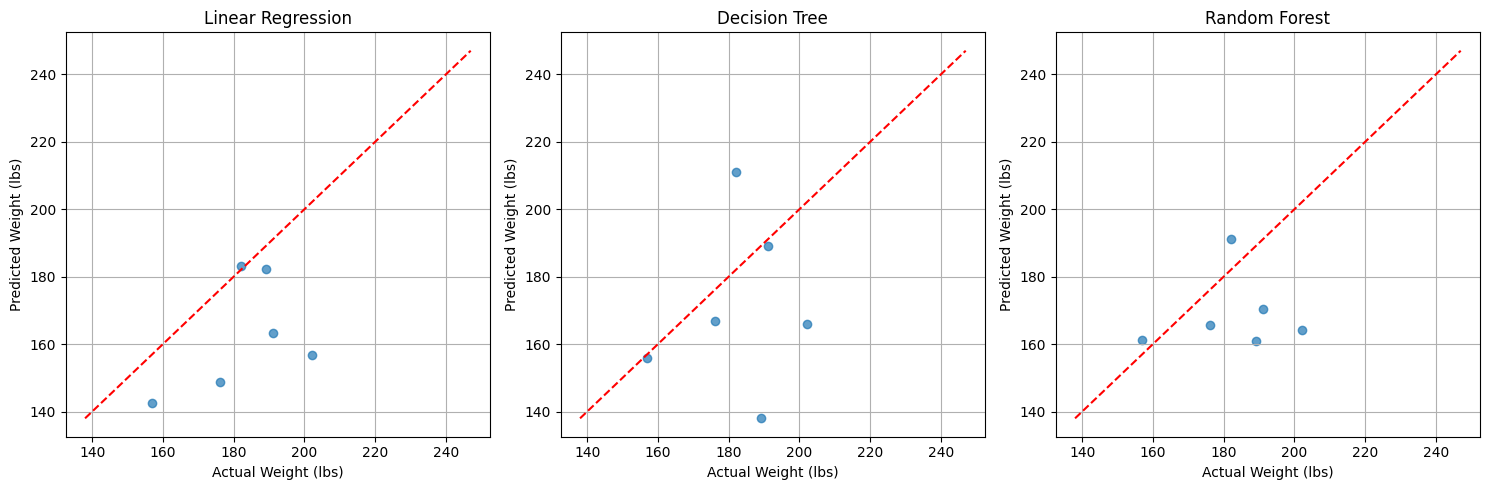

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, y_pred) in zip(axes, predictions.items()):
    ax.scatter(y_test, y_pred, alpha=0.7)
    ax.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
    ax.set_xlabel('Actual Weight (lbs)')
    ax.set_ylabel('Predicted Weight (lbs)')
    ax.set_title(name)
    ax.grid(True)

plt.tight_layout()
plt.show()

## Step 9: Predict on New Custom Data

Use your trained models to predict weight for a new person based on their exercise numbers!

In [11]:
# New person: 10 chin-ups, 100 sit-ups, 40 jumps
new_person = np.array([[10, 100, 40]])

print("Predictions for new person (10 Chins, 100 Situps, 40 Jumps):")
for name, model in models.items():
    pred = model.predict(new_person)[0]
    print(f"  {name}: {pred:.1f} lbs")

Predictions for new person (10 Chins, 100 Situps, 40 Jumps):
  Linear Regression: 185.2 lbs
  Decision Tree: 211.0 lbs
  Random Forest: 199.8 lbs


## Full Working Code (Copy-Paste)

Linear Regression - MSE: 632.89, R²: -2.1996
Decision Tree - MSE: 804.00, R²: -3.0646
Random Forest - MSE: 473.28, R²: -1.3926


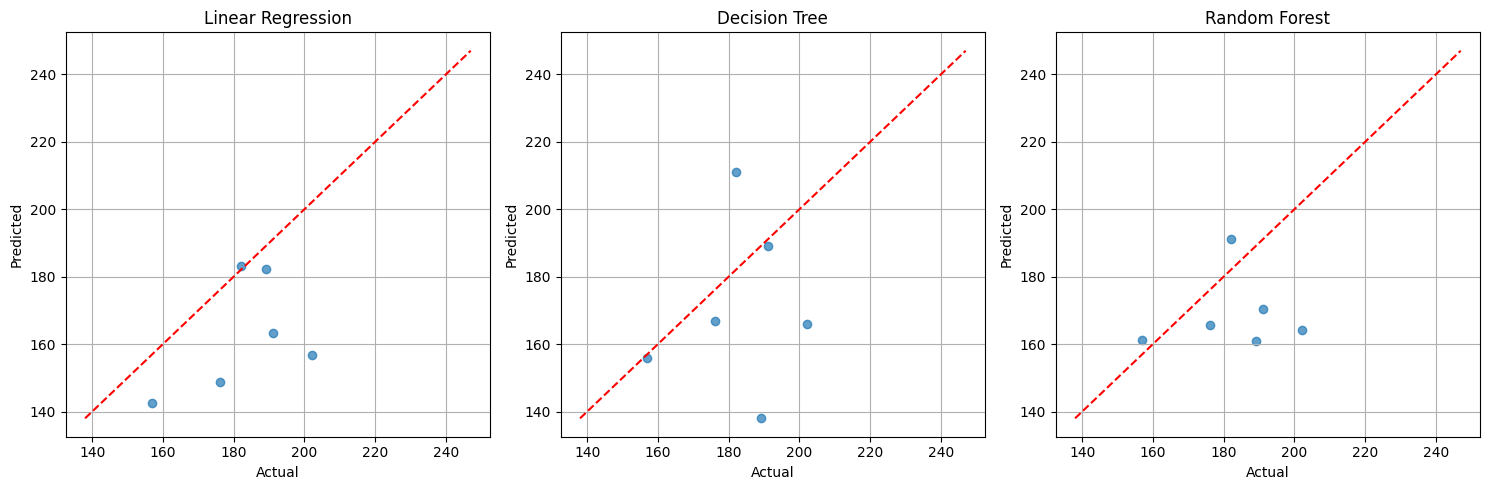

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_linnerud
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
linnerud = load_linnerud()
X = linnerud.data
y = linnerud.target[:, 0]  # Predict Weight

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Train models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42)
}

predictions = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions[name] = model.predict(X_test)

# Evaluate
for name, y_pred in predictions.items():
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"{name} - MSE: {mse:.2f}, R²: {r2:.4f}")

# Plot results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (name, y_pred) in zip(axes, predictions.items()):
    ax.scatter(y_test, y_pred, alpha=0.7)
    ax.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(name)
    ax.grid(True)
plt.tight_layout()
plt.show()

## Key Takeaways
- **scikit-learn workflow**: Load → Split → Train → Predict → Evaluate
- **Regression**: Predicts continuous values (e.g., Weight)
- **Linear Regression**: Fast, interpretable baseline; coefficients show feature impact
- **Decision Tree**: Can capture non-linear patterns but may overfit on small data
- **Random Forest**: Ensemble method that often outperforms single trees
- **Comparison**: Always compare multiple models to find the best fit for your data

**Next steps**: Try predicting other targets (Waist, Pulse) or tune hyperparameters!